In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

model = joblib.load("../models/improved_logistic_regression_model.pkl")

elo_table = pd.read_csv("../data/processed/latest_elo_ratings.csv")

latest_elo = dict(
    zip(elo_table["team"], elo_table["elo_rating"])
)

elo_table.head()

,team,elo_rating
0,France,2020.978628
1,Argentina,2012.407294
2,Spain,2009.617685
3,Brazil,1952.069309
4,England,1950.041412


In [2]:
def predict_match(home_team, away_team, neutral=True):
    home_elo = latest_elo.get(home_team, 1500)
    away_elo = latest_elo.get(away_team, 1500)

    elo_difference = home_elo - away_elo
    home_advantage = 0 if neutral else 1

    X_match = pd.DataFrame([
        {
            "elo_difference": elo_difference,
            "home_advantage": home_advantage,
        }
    ])

    probabilities = model.predict_proba(X_match)[0]

    return dict(zip(model.classes_, probabilities))

In [3]:
predict_match("Argentina", "France")

{'away_win': np.float64(0.3481592995924308),
 'draw': np.float64(0.25353075923684004),
 'home_win': np.float64(0.39830994117072926)}

In [4]:
def simulate_match(home_team, away_team, neutral=True):
    probabilities = predict_match(home_team, away_team, neutral)

    outcomes = list(probabilities.keys())
    probs = list(probabilities.values())

    result = np.random.choice(outcomes, p=probs)

    return result

In [6]:
def get_group_points(result):
    if result == "home_win":
        return 3, 0

    if result == "away_win":
        return 0, 3

    return 1, 1

def generate_group_fixtures(teams):
    fixtures = []

    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            fixtures.append((teams[i], teams[j]))

    return fixtures

In [7]:
def simulate_group(teams):
    standings = {}

    for team in teams:
        standings[team] = {
            "points": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
        }

    fixtures = generate_group_fixtures(teams)

    for home_team, away_team in fixtures:
        result = simulate_match(home_team, away_team, neutral=True)

        home_points, away_points = get_group_points(result)

        standings[home_team]["points"] += home_points
        standings[away_team]["points"] += away_points

        if result == "home_win":
            standings[home_team]["wins"] += 1
            standings[away_team]["losses"] += 1

        elif result == "away_win":
            standings[away_team]["wins"] += 1
            standings[home_team]["losses"] += 1

        else:
            standings[home_team]["draws"] += 1
            standings[away_team]["draws"] += 1

    ranked_teams = sorted(
        standings.items(),
        key=lambda item: item[1]["points"],
        reverse=True
    )

    return ranked_teams

In [8]:
def simulate_knockout_match(home_team, away_team):
    probabilities = predict_match(home_team, away_team, neutral=True)

    home_prob = probabilities.get("home_win", 0)
    away_prob = probabilities.get("away_win", 0)

    total = home_prob + away_prob

    if total == 0:
        return np.random.choice([home_team, away_team])

    home_advances_prob = home_prob / total

    winner = np.random.choice(
        [home_team, away_team],
        p=[home_advances_prob, 1 - home_advances_prob]
    )

    return winner

groups = {
    "Group A": ["Argentina", "France", "Japan", "Canada"],
    "Group B": ["Brazil", "Spain", "Germany", "Morocco"],
}


In [10]:
def simulate_tournament(groups):
    group_a = simulate_group(groups["Group A"])
    group_b = simulate_group(groups["Group B"])

    a1 = group_a[0][0]
    a2 = group_a[1][0]

    b1 = group_b[0][0]
    b2 = group_b[1][0]

    semifinal_1_winner = simulate_knockout_match(a1, b2)
    semifinal_2_winner = simulate_knockout_match(b1, a2)

    champion = simulate_knockout_match(
        semifinal_1_winner,
        semifinal_2_winner
    )

    return champion
simulate_tournament(groups)


np.str_('Brazil')

In [12]:
num_simulations = 10000

champions = []

for _ in range(num_simulations):
    champion = simulate_tournament(groups)
    champions.append(champion)

champion_probs = (
    pd.Series(champions)
    .value_counts(normalize=True)
    .sort_values(ascending=False)
)

champion_probs

Argentina    0.2878
France       0.2718
Spain        0.2216
Brazil       0.1119
Germany      0.0572
Japan        0.0267
Morocco      0.0212
Canada       0.0018
Name: proportion, dtype: float64

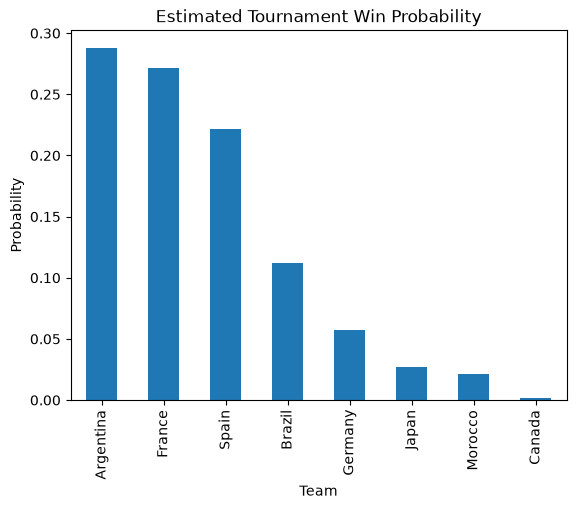

In [13]:
champion_probs.plot(kind="bar")

plt.title("Estimated Tournament Win Probability")
plt.ylabel("Probability")
plt.xlabel("Team")

plt.show()